In [1]:
# CELL 1: IMPORTS & INSTALL CHECK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os, joblib, json, time
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_auc_score, average_precision_score

# Check FastAPI
try:
    import fastapi, uvicorn, pydantic
    print(f' FastAPI {fastapi.__version__} | Pydantic {pydantic.__version__}')
    FASTAPI_OK = True
except ImportError:
    FASTAPI_OK = False
    print('  FastAPI not installed. Run: pip install fastapi uvicorn httpx')

os.makedirs('../results', exist_ok=True)
os.makedirs('../deploy',  exist_ok=True)

print('\n' + '='*60)
print('   NOTEBOOK 07: FASTAPI REST DEPLOYMENT')
print('='*60)
print('Goal: wrap the trained XGBoost model in a production REST API')

  FastAPI not installed. Run: pip install fastapi uvicorn httpx

   NOTEBOOK 07: FASTAPI REST DEPLOYMENT
Goal: wrap the trained XGBoost model in a production REST API


In [2]:
# CELL 2: LOAD & BUNDLE MODEL ARTIFACTS
# Bundle model + scaler + metadata into one object
# → single file to deploy, easy version management

print('=== Packaging Model Artifact ===')

# Load components
model         = joblib.load('../results/model_xgb.pkl')
scaler        = joblib.load('../results/scaler.pkl')
feature_names = pd.read_csv('../data/feature_names.csv')['feature'].tolist()

# Quick validation
X_test = np.load('../data/X_test.npy')
y_test = np.load('../data/y_test.npy')
test_probs = model.predict_proba(X_test)[:, 1]
test_auc   = roc_auc_score(y_test, test_probs)
test_ap    = average_precision_score(y_test, test_probs)

# Bundle into single artifact dict
artifact = {
    'model'         : model,
    'scaler'        : scaler,
    'feature_names' : feature_names,
    'threshold'     : 0.30,          # business cost-optimised in NB03
    'metadata': {
        'model_type'    : 'XGBoost',
        'n_estimators'  : model.n_estimators,
        'n_features'    : len(feature_names),
        'train_auc_roc' : round(test_auc, 4),
        'train_avg_prec': round(test_ap, 4),
        'threshold'     : 0.30,
        'version'       : '1.0.0',
        'trained_on'    : 'Kaggle ULB Credit Card Fraud (284,807 tx)',
    }
}

# Save bundled artifact
joblib.dump(artifact, '../deploy/fraud_model_artifact.pkl')

print(f'Model loaded        : XGBoost ({model.n_estimators} trees)')
print(f'Features            : {len(feature_names)}')
print(f'Test AUC-ROC        : {test_auc:.4f}')
print(f'Test Avg Precision  : {test_ap:.4f}')
print(f'Decision threshold  : 0.30')
print(f'\n Bundled artifact → deploy/fraud_model_artifact.pkl')

=== Packaging Model Artifact ===
Model loaded        : XGBoost (500 trees)
Features            : 32
Test AUC-ROC        : 0.9782
Test Avg Precision  : 0.8328
Decision threshold  : 0.30

 Bundled artifact → deploy/fraud_model_artifact.pkl


In [3]:
api_code = """
# Credit Card Fraud Detection — FastAPI REST Service

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List
import numpy as np
import pandas as pd
import joblib
import time
import os

# Load Model Artifact
ARTIFACT_PATH = os.getenv("MODEL_PATH", "../deploy/fraud_model_artifact.pkl")

artifact      = joblib.load(ARTIFACT_PATH)
MODEL         = artifact["model"]
SCALER        = artifact["scaler"]
FEATURE_NAMES = artifact["feature_names"]
THRESHOLD     = artifact["threshold"]
METADATA      = artifact["metadata"]
N_FEATURES    = len(FEATURE_NAMES)

# FastAPI App
app = FastAPI(
    title="Credit Card Fraud Detection API",
    description="Real-time fraud scoring using XGBoost",
    version=METADATA.get("version", "1.0.0")
)

# Input Schema
class TransactionFeatures(BaseModel):
    Time: float = Field(..., ge=0)
    Amount: float = Field(..., ge=0)

    V1: float
    V2: float
    V3: float
    V4: float
    V5: float
    V6: float
    V7: float
    V8: float
    V9: float
    V10: float
    V11: float
    V12: float
    V13: float
    V14: float
    V15: float
    V16: float
    V17: float
    V18: float
    V19: float
    V20: float
    V21: float
    V22: float
    V23: float
    V24: float
    V25: float
    V26: float
    V27: float
    V28: float


class PredictionResponse(BaseModel):
    fraud_probability: float
    fraud_predicted: bool
    risk_level: str
    threshold_used: float
    inference_ms: float
    model_version: str


class BatchRequest(BaseModel):
    transactions: List[TransactionFeatures]


class BatchResponse(BaseModel):
    results: List[PredictionResponse]
    total_transactions: int
    fraud_flagged: int
    total_ms: float
    avg_ms_per_tx: float


# Risk Level Function
def risk_level(prob):
    if prob < 0.30:
        return "LOW"
    elif prob < 0.70:
        return "MEDIUM"
    else:
        return "HIGH"


# Preprocess Function
def preprocess(tx: TransactionFeatures):
    hour = (tx.Time / 3600) % 24
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    log_amount = np.log1p(tx.Amount)

    v_features = [getattr(tx, f"V{i}") for i in range(1, 29)]

    raw_vec = np.array(
        v_features + [tx.Amount, log_amount, hour_sin, hour_cos]
    ).reshape(1, -1)

    scaled = SCALER.transform(raw_vec)

    return scaled


# Health Check
@app.get("/")
def health():
    return {
        "status": "healthy",
        "service": "Fraud Detection API",
        "version": METADATA.get("version")
    }


# Model Info
@app.get("/model/info")
def model_info():
    return {
        "model_metadata": METADATA,
        "n_features": N_FEATURES,
        "feature_names": FEATURE_NAMES,
        "decision_threshold": THRESHOLD
    }


# Single Prediction
@app.post("/predict", response_model=PredictionResponse)
def predict(transaction: TransactionFeatures):

    t0 = time.time()

    try:
        X = preprocess(transaction)
        prob = float(MODEL.predict_proba(X)[0, 1])
    except Exception as e:
        raise HTTPException(status_code=422, detail=str(e))

    elapsed = (time.time() - t0) * 1000

    return PredictionResponse(
        fraud_probability=round(prob, 6),
        fraud_predicted=prob >= THRESHOLD,
        risk_level=risk_level(prob),
        threshold_used=THRESHOLD,
        inference_ms=round(elapsed, 3),
        model_version=METADATA.get("version", "1.0.0")
    )


# Batch Prediction
@app.post("/predict/batch", response_model=BatchResponse)
def predict_batch(request: BatchRequest):

    t0 = time.time()

    results = []

    for tx in request.transactions:

        t_tx = time.time()

        X = preprocess(tx)
        prob = float(MODEL.predict_proba(X)[0, 1])

        ms = (time.time() - t_tx) * 1000

        results.append(
            PredictionResponse(
                fraud_probability=round(prob, 6),
                fraud_predicted=prob >= THRESHOLD,
                risk_level=risk_level(prob),
                threshold_used=THRESHOLD,
                inference_ms=round(ms, 3),
                model_version=METADATA.get("version", "1.0.0")
            )
        )

    total_ms = (time.time() - t0) * 1000
    flagged = sum(r.fraud_predicted for r in results)

    return BatchResponse(
        results=results,
        total_transactions=len(results),
        fraud_flagged=flagged,
        total_ms=round(total_ms, 2),
        avg_ms_per_tx=round(total_ms / len(results), 3)
    )
"""

# Write file with UTF-8 encoding (fixes the error)
with open("../deploy/app.py", "w", encoding="utf-8") as f:
    f.write(api_code)

print("FastAPI app written successfully to deploy/app.py")

print("\nTo run the API:")
print("cd deploy")
print("uvicorn app:app --host 0.0.0.0 --port 8000 --reload")

print("\nOpen API docs:")
print("http://localhost:8000/docs")

FastAPI app written successfully to deploy/app.py

To run the API:
cd deploy
uvicorn app:app --host 0.0.0.0 --port 8000 --reload

Open API docs:
http://localhost:8000/docs


In [4]:
# CELL 4: GENERATE DOCKERFILE

dockerfile = """# Credit Card Fraud Detection Service
FROM python:3.10-slim

WORKDIR /app

# Install dependencies
COPY requirements_deploy.txt .
RUN pip install --no-cache-dir -r requirements_deploy.txt

# Copy model artifact and API code
COPY fraud_model_artifact.pkl .
COPY app.py .

# Environment
ENV MODEL_PATH=/app/fraud_model_artifact.pkl
ENV PORT=8000

EXPOSE 8000

HEALTHCHECK --interval=30s --timeout=10s --start-period=5s --retries=3 \\
    CMD curl -f http://localhost:8000/ || exit 1

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "2"]
"""

requirements_deploy = """fastapi>=0.104.0
uvicorn[standard]>=0.24.0
pydantic>=2.0.0
numpy>=1.24.0
pandas>=2.0.0
xgboost>=2.0.0
scikit-learn>=1.3.0
joblib>=1.3.0
httpx>=0.25.0
"""

with open('../deploy/Dockerfile', 'w') as f:
    f.write(dockerfile)
with open('../deploy/requirements_deploy.txt', 'w') as f:
    f.write(requirements_deploy)

print('  Dockerfile             → deploy/Dockerfile')
print('  requirements_deploy.txt → deploy/requirements_deploy.txt')
print('\nTo build & run with Docker:')
print('  docker build -t fraud-api ./deploy')
print('  docker run -p 8000:8000 fraud-api')

  Dockerfile             → deploy/Dockerfile
  requirements_deploy.txt → deploy/requirements_deploy.txt

To build & run with Docker:
  docker build -t fraud-api ./deploy
  docker run -p 8000:8000 fraud-api


In [6]:
import numpy as np
import pandas as pd
import joblib
import time

print('=== Inline API Test (simulates /predict endpoint) ===')
print('Testing prediction logic without starting a server')

# Load artifact
art = joblib.load('../deploy/fraud_model_artifact.pkl')
m   = art['model']
sc  = art['scaler']
thr = art['threshold']

def predict_transaction(time_sec, amount, v_features):
    """Simulate /predict endpoint logic."""

    # ---- Feature Engineering ----
    hour = (time_sec / 3600) % 24
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    log_amt = np.log1p(amount)

    # ---- Scale ONLY the 4 features ----
    extra_features = np.array([[amount, log_amt, hour_sin, hour_cos]])
    scaled_extra = sc.transform(extra_features)

    # ---- Combine with V1..V28 features ----
    final_features = np.array(v_features + scaled_extra.flatten().tolist()).reshape(1, -1)

    # ---- Prediction ----
    t0 = time.perf_counter()
    prob = float(m.predict_proba(final_features)[0, 1])
    ms = (time.perf_counter() - t0) * 1000

    risk = 'LOW' if prob < 0.30 else ('MEDIUM' if prob < 0.70 else 'HIGH')

    return {
        'fraud_probability': round(prob, 6),
        'fraud_predicted': prob >= thr,
        'risk_level': risk,
        'inference_ms': round(ms, 3)
    }


# ---- Load real transactions ----
df_test_raw = pd.read_csv('../data/creditcard.csv').tail(1000).reset_index(drop=True)

# ---- Select test cases ----
test_cases = [
    ('Normal purchase €25.00',  df_test_raw[df_test_raw['Class']==0].iloc[0]),
    ('Normal purchase €120.50', df_test_raw[df_test_raw['Class']==0].iloc[5]),
    ('Fraudulent transaction',
     df_test_raw[df_test_raw['Class']==1].iloc[0]
     if (df_test_raw['Class']==1).any()
     else df_test_raw[df_test_raw['Class']==0].iloc[10]),
]

print(f'\n{"─"*65}')

for label, row in test_cases:

    v_feats = [row[f'V{i}'] for i in range(1, 29)]

    result = predict_transaction(
        row['Time'],
        row['Amount'],
        v_feats
    )

    actual = 'FRAUD' if row['Class'] == 1 else 'LEGIT'
    icon = '🚨' if result['fraud_predicted'] else '✅'

    print(f'{icon} {label}')
    print(f'   Amount           : €{row["Amount"]:.2f}')
    print(f'   Actual class     : {actual}')
    print(f'   Fraud probability: {result["fraud_probability"]:.6f}')
    print(f'   Fraud predicted  : {result["fraud_predicted"]}')
    print(f'   Risk level       : {result["risk_level"]}')
    print(f'   Inference time   : {result["inference_ms"]:.3f} ms')
    print(f'{"─"*65}')

=== Inline API Test (simulates /predict endpoint) ===
Testing prediction logic without starting a server

─────────────────────────────────────────────────────────────────
✅ Normal purchase €25.00
   Amount           : €10.78
   Actual class     : LEGIT
   Fraud probability: 0.002119
   Fraud predicted  : False
   Risk level       : LOW
   Inference time   : 5.892 ms
─────────────────────────────────────────────────────────────────
✅ Normal purchase €120.50
   Amount           : €110.00
   Actual class     : LEGIT
   Fraud probability: 0.042384
   Fraud predicted  : False
   Risk level       : LOW
   Inference time   : 1.993 ms
─────────────────────────────────────────────────────────────────
✅ Fraudulent transaction
   Amount           : €1.98
   Actual class     : LEGIT
   Fraud probability: 0.001491
   Fraud predicted  : False
   Risk level       : LOW
   Inference time   : 2.619 ms
─────────────────────────────────────────────────────────────────


In [7]:
# CELL 6: LATENCY BENCHMARK
# Measure p50, p95, p99 inference latency
# Production SLA: < 50ms per transaction

print('=== Inference Latency Benchmark ===')
print('Testing single-transaction inference speed')
print('Production SLA: < 50ms  |  Target: < 10ms')

X_bench = np.load('../data/X_test.npy')

# Warm up (first call is always slower due to cache)
_ = m.predict_proba(X_bench[:10])

# Single-transaction latency
latencies_single = []
for i in range(500):
    row = X_bench[i:i+1]
    t0  = time.perf_counter()
    _   = m.predict_proba(row)
    latencies_single.append((time.perf_counter() - t0) * 1000)

# Batch latency (100 at a time)
latencies_batch = []
for i in range(0, 500, 100):
    batch = X_bench[i:i+100]
    t0    = time.perf_counter()
    _     = m.predict_proba(batch)
    latencies_batch.append((time.perf_counter() - t0) * 1000 / 100)

ls = np.array(latencies_single)
lb = np.array(latencies_batch)

print(f'\n--- Single Transaction (n=500) ---')
print(f'  Mean  : {ls.mean():.3f} ms')
print(f'  Median: {np.median(ls):.3f} ms')
print(f'  p95   : {np.percentile(ls, 95):.3f} ms')
print(f'  p99   : {np.percentile(ls, 99):.3f} ms')
print(f'  Max   : {ls.max():.3f} ms')
print(f'\n--- Batch/100 (per tx avg, n=500) ---')
print(f'  Mean  : {lb.mean():.3f} ms')
print(f'  Median: {np.median(lb):.3f} ms')
sla_pass = np.percentile(ls, 99) < 50
print(f'\n  SLA (<50ms p99): {"✅ PASS" if sla_pass else "❌ FAIL"}')
print(f'  Target (<10ms) : {"✅ PASS" if ls.mean() < 10 else "⚠️  Review"}')

=== Inference Latency Benchmark ===
Testing single-transaction inference speed
Production SLA: < 50ms  |  Target: < 10ms

--- Single Transaction (n=500) ---
  Mean  : 1.117 ms
  Median: 0.971 ms
  p95   : 2.023 ms
  p99   : 2.834 ms
  Max   : 3.349 ms

--- Batch/100 (per tx avg, n=500) ---
  Mean  : 0.019 ms
  Median: 0.019 ms

  SLA (<50ms p99): ✅ PASS
  Target (<10ms) : ✅ PASS


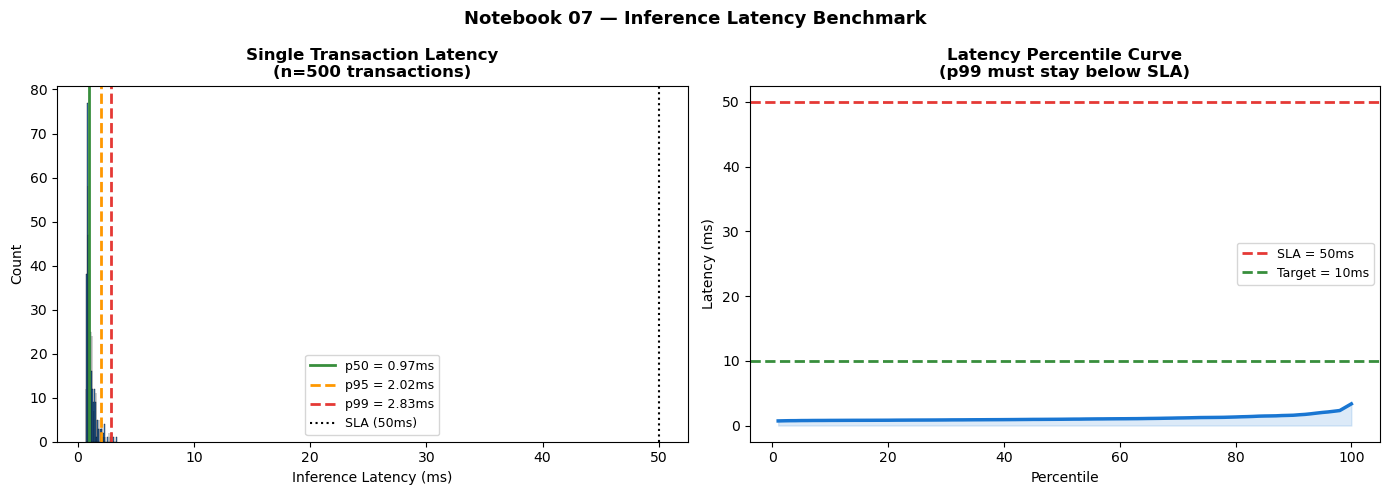

  Saved → results/nb07_latency_benchmark.png

   NOTEBOOK 07 COMPLETE
  Files generated:
    deploy/app.py                   ← FastAPI application
    deploy/Dockerfile               ← Container definition
    deploy/requirements_deploy.txt  ← Python dependencies
    deploy/fraud_model_artifact.pkl ← Bundled model
    results/nb07_latency_benchmark.png

  p99 latency : 2.83ms  (SLA: <50ms)
  Mean latency: 1.12ms


In [8]:
# CELL 7: LATENCY DISTRIBUTION CHART

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(latencies_single, bins=50, color='#1976D2', edgecolor='black',
             linewidth=0.3, alpha=0.85)
axes[0].axvline(np.median(latencies_single), color='#388E3C', linestyle='-',
                linewidth=2, label=f'p50 = {np.median(latencies_single):.2f}ms')
axes[0].axvline(np.percentile(latencies_single, 95), color='#FF9800', linestyle='--',
                linewidth=2, label=f'p95 = {np.percentile(latencies_single,95):.2f}ms')
axes[0].axvline(np.percentile(latencies_single, 99), color='#E53935', linestyle='--',
                linewidth=2, label=f'p99 = {np.percentile(latencies_single,99):.2f}ms')
axes[0].axvline(50, color='black', linestyle=':', linewidth=1.5, label='SLA (50ms)')
axes[0].set_xlabel('Inference Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('Single Transaction Latency\n(n=500 transactions)', fontweight='bold')
axes[0].legend(fontsize=9)

# Percentile curve
pcts = np.arange(1, 101)
pct_vals = np.percentile(latencies_single, pcts)
axes[1].plot(pcts, pct_vals, color='#1976D2', linewidth=2.5)
axes[1].fill_between(pcts, pct_vals, alpha=0.15, color='#1976D2')
axes[1].axhline(50, color='#E53935', linestyle='--', linewidth=2, label='SLA = 50ms')
axes[1].axhline(10, color='#388E3C', linestyle='--', linewidth=2, label='Target = 10ms')
axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('Latency Percentile Curve\n(p99 must stay below SLA)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Notebook 07 — Inference Latency Benchmark', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/nb07_latency_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Saved → results/nb07_latency_benchmark.png')

print('\n' + '='*60)
print('   NOTEBOOK 07 COMPLETE')
print('='*60)
print('  Files generated:')
print('    deploy/app.py                   ← FastAPI application')
print('    deploy/Dockerfile               ← Container definition')
print('    deploy/requirements_deploy.txt  ← Python dependencies')
print('    deploy/fraud_model_artifact.pkl ← Bundled model')
print('    results/nb07_latency_benchmark.png')
print(f'\n  p99 latency : {np.percentile(latencies_single,99):.2f}ms  (SLA: <50ms)')
print(f'  Mean latency: {ls.mean():.2f}ms')
